# Sistem Rekomendasi Skyline : Better Service, Best Satisfaction

Dashboard Streamlit PoC ini menerapkan pendekatan hybrid recommendation system dengan ensemble-based machine learning model, di mana CatBoost digunakan untuk memprediksi tingkat kepuasan atau confidence rekomendasi, kemudian hasil prediksi tersebut dikombinasikan dengan rule-based logic, segment analysis, dan business impact simulation untuk menghasilkan rekomendasi layanan penerbangan yang personal dan relevan bagi kebutuhan bisnis B2B maskapai.

In [12]:
import pandas as pd

df = pd.read_csv("D:\PENS-EEPIS\SDT A Semester 4 2026\Sistem Rekomendasi\Projek Mini\Airline Quality Ratings.csv")
print(df.shape)

(129880, 24)


In [13]:
df.head()

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,...,3,4,4,5,4,3,3,3,3,Satisfied


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   ID                                      129880 non-null  int64  
 1   Gender                                  129880 non-null  object 
 2   Age                                     129880 non-null  int64  
 3   Customer Type                           129880 non-null  object 
 4   Type of Travel                          129880 non-null  object 
 5   Class                                   129880 non-null  object 
 6   Flight Distance                         129880 non-null  int64  
 7   Departure Delay                         129880 non-null  int64  
 8   Arrival Delay                           129487 non-null  float64
 9   Departure and Arrival Time Convenience  129880 non-null  int64  
 10  Ease of Online Booking                  1298

## Keterangan Fitur:

ID: Passenger ID

Gender: Passenger gender

Age: Passenger age

Customer Type: The customer type

Type of Travel: Purpose of the flight of the passengers

Class: Travel class in the plane of the passengers

Flight Distance: Flight distance

Departure Delay: Minutes delayed when departure

Arrival Delay: Minutes delayed when Arrival

Departure & Arrival Time Сonvenience: Convenience of departure and arrival times for passengers

Ease of Online Booking: Easy to book

Check-in Service: Ease of registration

Online Boarding: Convenience of online registration

Gate Location: Gate Location Estimation

On-board Service: Service on board

Seat Comfort: Comfortable seating

Leg Room Service: Leg room service level

Cleanliness: Cleanliness level

Food and Drink: Quality of food and drinks

In-flight Service: Level of service on board

In-flight Wifi Service: Wifi quality level on board

In-flight Entertainment: Rating of in-flight entertainment

Baggage Handling: Opinion on baggage handling

Satisfaction: Airline satisfaction level

In [18]:
df.isnull().sum()
df.fillna(0, inplace=True)

In [16]:
# Pembagian fitur berdasarkan kategori

customer_features = [
    'Gender',
    'Age',
    'Customer Type',
    'Type of Travel',
    'Class'
]

service_quality_features = [
    'Departure and Arrival Time Convenience',
    'Ease of Online Booking',
    'Check-in Service',
    'Online Boarding',
    'Gate Location',
    'On-board Service',
    'Seat Comfort',
    'Leg Room Service',
    'Cleanliness',
    'Food and Drink',
    'In-flight Service',
    'In-flight Wifi Service',
    'In-flight Entertainment',
    'Baggage Handling'
]

operational_features = [
    'Flight Distance',
    'Departure Delay',
    'Arrival Delay'
]

target_variable = 'Satisfaction'

In [19]:
# Customer Features

print("=" * 50)
print("CUSTOMER FEATURES")
print("=" * 50)

for col in customer_features:
    print(f"\nValue counts untuk fitur '{col}':")
    print(df[col].value_counts())

CUSTOMER FEATURES

Value counts untuk fitur 'Gender':
Gender
Female    65899
Male      63981
Name: count, dtype: int64

Value counts untuk fitur 'Age':
Age
39    3692
25    3511
40    3209
44    3104
41    3089
      ... 
74      61
76      60
79      52
78      44
85      25
Name: count, Length: 75, dtype: int64

Value counts untuk fitur 'Customer Type':
Customer Type
Returning     106100
First-time     23780
Name: count, dtype: int64

Value counts untuk fitur 'Type of Travel':
Type of Travel
Business    89693
Personal    40187
Name: count, dtype: int64

Value counts untuk fitur 'Class':
Class
Business        62160
Economy         58309
Economy Plus     9411
Name: count, dtype: int64


In [20]:
# Service Quality Features

print("=" * 50)
print("SERVICE QUALITY FEATURES")
print("=" * 50)

for col in service_quality_features:
    print(f"\nValue counts untuk fitur '{col}':")
    print(df[col].value_counts().sort_index())

SERVICE QUALITY FEATURES

Value counts untuk fitur 'Departure and Arrival Time Convenience':
Departure and Arrival Time Convenience
0     6681
1    19409
2    21534
3    22378
4    31880
5    27998
Name: count, dtype: int64

Value counts untuk fitur 'Ease of Online Booking':
Ease of Online Booking
0     5682
1    21886
2    30051
3    30393
4    24444
5    17424
Name: count, dtype: int64

Value counts untuk fitur 'Check-in Service':
Check-in Service
0        1
1    16108
2    16102
3    35453
4    36333
5    25883
Name: count, dtype: int64

Value counts untuk fitur 'Online Boarding':
Online Boarding
0     3080
1    13261
2    21934
3    27117
4    38468
5    26020
Name: count, dtype: int64

Value counts untuk fitur 'Gate Location':
Gate Location
0        1
1    21991
2    24296
3    35717
4    30466
5    17409
Name: count, dtype: int64

Value counts untuk fitur 'On-board Service':
On-board Service
0        5
1    14787
2    18351
3    28542
4    38703
5    29492
Name: count, dtype: int

In [21]:
# Operational Features

print("=" * 50)
print("OPERATIONAL FEATURES")
print("=" * 50)

for col in operational_features:
    print(f"\nStatistik deskriptif untuk fitur '{col}':")
    print(df[col].describe())

    print(f"\nTop 10 value counts untuk fitur '{col}':")
    print(df[col].value_counts().head(10))


OPERATIONAL FEATURES

Statistik deskriptif untuk fitur 'Flight Distance':
count    129880.000000
mean       1190.316392
std         997.452477
min          31.000000
25%         414.000000
50%         844.000000
75%        1744.000000
max        4983.000000
Name: Flight Distance, dtype: float64

Top 10 value counts untuk fitur 'Flight Distance':
Flight Distance
337     841
594     505
404     480
862     473
2475    470
447     457
236     438
192     424
308     402
214     398
Name: count, dtype: int64

Statistik deskriptif untuk fitur 'Departure Delay':
count    129880.000000
mean         14.713713
std          38.071126
min           0.000000
25%           0.000000
50%           0.000000
75%          12.000000
max        1592.000000
Name: Departure Delay, dtype: float64

Top 10 value counts untuk fitur 'Departure Delay':
Departure Delay
0    73356
1     3682
2     2855
3     2535
4     2309
5     2136
6     1884
7     1748
8     1618
9     1552
Name: count, dtype: int64

Statistik 

In [22]:
# Target Variable

print("=" * 50)
print("TARGET VARIABLE")
print("=" * 50)

print(f"\nValue counts untuk target variable '{target_variable}':")
print(df[target_variable].value_counts())

print(f"\nPersentase target variable '{target_variable}':")
print(df[target_variable].value_counts(normalize=True) * 100)


TARGET VARIABLE

Value counts untuk target variable 'Satisfaction':
Satisfaction
Neutral or Dissatisfied    73452
Satisfied                  56428
Name: count, dtype: int64

Persentase target variable 'Satisfaction':
Satisfaction
Neutral or Dissatisfied    56.553742
Satisfied                  43.446258
Name: proportion, dtype: float64


C:\Users\Joshu\AppData\Local\Temp\ipykernel_29804\3420990789.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


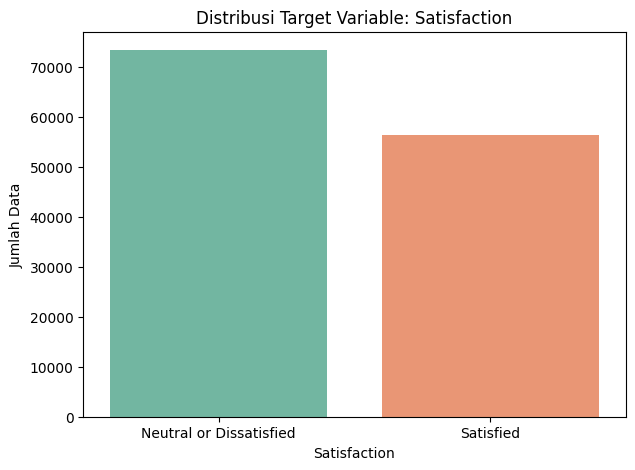

In [23]:
# Visualisasi Target Variable - Bar Chart
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
sns.countplot(
    data=df,
    x=target_variable,
    palette='Set2'
)

plt.title('Distribusi Target Variable: Satisfaction')
plt.xlabel('Satisfaction')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=0)
plt.show()

## Preprocessing

In [ ]:
import catboost as ctb
from sklearn.model_selection import train_test_split